In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
import seaborn as sns

In [25]:
results_dir = "/gpfs/radev/home/ap2853/paper_polish/results"

results = {}
for file in glob.glob(os.path.join(results_dir, "*.json")):
    filename = os.path.basename(file)
    with open(file, "r") as f:
        results[filename] = json.load(f)


In [32]:
scores = { model_name: {
    "strength": [],
    "weakness": [],
    "overall": []
} for model_name in results.keys()
}

for model_name, model_results in results.items():
    for result in model_results:
        if not result["generated_review"].strip():
            continue
        if result["review_type"] == "strength":
            scores[model_name]["strength"].append(result["bert_f1"])
        elif result["review_type"] == "weakness":
            scores[model_name]["weakness"].append(result["bert_f1"])
        
        scores[model_name]["overall"].append(result["bert_f1"])

average_scores = { model_name: {
    "strength": np.mean(scores[model_name]["strength"]),
    "weakness": np.mean(scores[model_name]["weakness"]),
    "overall": np.mean(scores[model_name]["overall"])
} for model_name in results.keys()
}

In [33]:
df = pd.DataFrame(average_scores)
df

,rank32_ckpt1000.json,rank128_ckpt1000.json,rank128_ckpt400.json,base_gemma3-4b.json
strength,0.830952,0.830907,0.828160,0.823655
weakness,0.818992,0.818543,0.816812,0.808805
overall,0.824972,0.824596,0.822486,0.816230


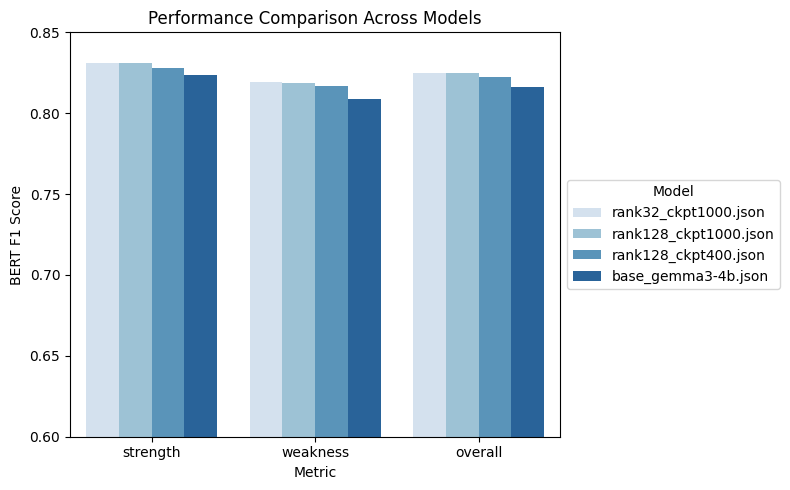

In [34]:
color_palette = sns.color_palette("Blues", len(df.columns))

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Reshape the dataframe for seaborn's grouped barplot
df_melted = df.reset_index().melt(id_vars='index', var_name='Model', value_name='Score')

# Create the grouped barplot
sns.barplot(x='index', y='Score', hue='Model', data=df_melted, palette="Blues")

# Add labels and title
plt.xlabel('Metric')
plt.ylabel('BERT F1 Score')
plt.title('Performance Comparison Across Models')

# Add a legend
plt.legend(title='Model', loc="center left", bbox_to_anchor=(1, 0.5))


ax.set_ylim(0.6, 0.85)

# Adjust layout
plt.tight_layout()

